In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import pandas as pd

from dusty_colors.utils import load_stack

In [74]:
correct_flip = False

result_dir = Path("../results")
# result_dir = Path("../results_original_jackknife")

results = {
    i: load_stack(
        result_dir / f"stacks/jackknife_{i}",
        stack_type="fcolors",
        r_norm=None,
        correct_flip=correct_flip,
    )
    for i in range(0, 17)
}

bg = pd.read_parquet(
    result_dir / "catalogs/default/galaxy_catalog_background_cleaned.parquet"
)
fg = pd.read_parquet(result_dir / "catalogs/default/galaxy_catalog_foreground.parquet")

pairs = np.load(result_dir / "stacks/jackknife_17/pairs.npz")

idx, count = np.unique(pairs["pairs"][:, 1], return_counts=True)
mask = np.isfinite(bg.iloc[idx]["g-i"])
idx, count = idx[mask], count[mask]
bg_avg = np.average(bg.iloc[idx]["g-i"], weights=count)

idx, count = np.unique(pairs["pairs"][:, 0], return_counts=True)
mask = np.isfinite(fg.iloc[idx]["g-i"])
idx, count = idx[mask], count[mask]
fg_avg = np.average(fg.iloc[idx]["g-i"], weights=count)

norm = bg_avg - fg_avg if correct_flip else bg_avg

# norm = 0.034154693505663504
# norm = 0.02338663827575135

0.07503713675914436


[Text(0.5, 0, 'Impact parameter [Mpc]'), None]

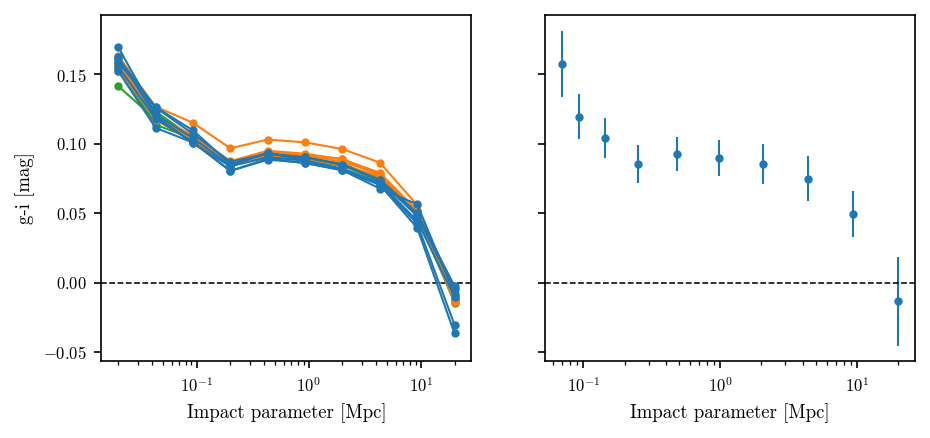

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), dpi=150, sharey=True)


def get_color(i):
    if i <= 5:
        return "C0"
    elif i <= 11:
        return "C1"
    else:
        return "C2"


y_all = []
for i in results:
    x = results[i]["g-i_bin_centers"]
    y = -2.5 * np.log10(results[i]["g-i_avg"]) - norm
    y_err = results[i]["g-i_err"]

    ax1.errorbar(
        x, y, yerr=y_err, label=f"JK {i}", marker=".", color=get_color(i), zorder=20 - i
    )
    y_all.append(y)

x_all = x.copy()
y_all = np.array(y_all)

y_mean = np.mean(y_all, axis=0)
print(y_mean[7])
# y_mean -= y_mean[4:8].mean()
y_cov = np.cov(y_all, rowvar=False, bias=True) * (len(y_all) - 1)


ax2.errorbar(x_all + 0.05, y_mean, yerr=np.sqrt(np.diag(y_cov)), marker=".", ls="")

ax1.axhline(0, c="k", ls="--", lw=0.75)
ax2.axhline(0, c="k", ls="--", lw=0.75)

ax1.set(xlabel="Impact parameter [Mpc]", ylabel="g-i [mag]", xscale="log")
ax2.set(xlabel="Impact parameter [Mpc]", xscale="log")
# plt.legend()

In [78]:
np.rad2deg(20 / 926.9)

np.float64(1.2362882622307114)

Best fit power law:
    scale = 8.4e-02 ± 5.6e-03
    index = -0.13 ± 0.03


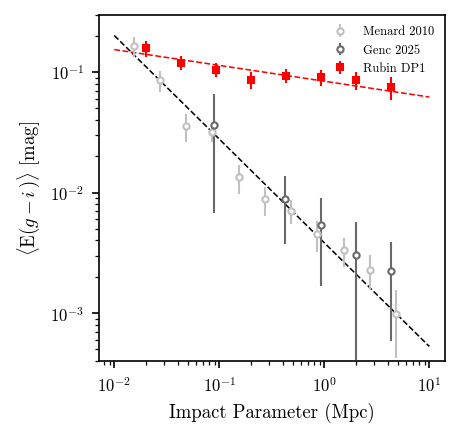

In [69]:
# Digitization of previous results
menard = np.array(
    [
        0.015372588004246894,
        0.16363373083250488,
        0.027147818672390675,
        0.08523850777558134,
        0.04794274447902959,
        0.03541057247645705,
        0.08584894051000302,
        0.03183392387526768,
        0.15372588004246884,
        0.013401938789527565,
        0.2714781867239069,
        0.008753798222678313,
        0.48612391624802315,
        0.007074748123832496,
        0.8584894051000298,
        0.004499654732304847,
        1.537258800424686,
        0.0033130745918951094,
        2.7147818672390636,
        0.0022823461023140207,
        4.861239162480231,
        0.0009867784425089342,
        0.015372588004246894,
        0.19454377598866124,
        0.027147818672390675,
        0.10269769440034786,
        0.04794274447902959,
        0.04440162288571723,
        0.08584894051000302,
        0.03734688077726687,
        0.15372588004246884,
        0.017029969604826688,
        0.2714781867239069,
        0.011123533691669145,
        0.48612391624802315,
        0.008638059376211973,
        0.8584894051000298,
        0.005794364085237468,
        1.537258800424686,
        0.00420995502849078,
        2.7147818672390636,
        0.0030183443573722673,
        4.794274447902952,
        0.0015514988038209934,
    ]
)
menard = menard.reshape(22, 2)

menard_x = menard[:11, 0]
menard_y = menard[:11, 1]

menard_err = menard[11:, 1] - menard_y

# TODO: Add upper limits
kids = np.array(
    [
        0.2952434728405713,
        0.011686711085103491,
        1.3939400795413572,
        0.002833398713044844,
        3.028837722476841,
        0.0017255322353215614,
        6.581242683055025,
        0.0009789696561929445,
        14.300124081209015,
        0.000716777914648752,
        0.2952434728405713,
        0.021191116846058046,
        1.3939400795413572,
        0.004458931178088874,
        3.028837722476841,
        0.0029148444562188815,
        6.581242683055025,
        0.0018261584682702627,
        14.300124081209015,
        0.0012456172541058495,
    ]
)
kids = kids.reshape(10, 2)

kids_x = kids[:5, 0]
kids_y = kids[:5, 1]

kids_err = kids[5:, 1] - kids_y

# Convert arcmin -> Mpc
arcmin_per_Mpc = 1e3 / (5.078 * 60)
kids_x /= arcmin_per_Mpc

# Convert Av -> reddening
Rv = 3.1
kids_y *= Rv
kids_err *= Rv

fig, ax1 = plt.subplots(figsize=(3, 3), dpi=150)

x = np.logspace(-2, 1, 100)
y = x**-0.86 * np.mean(menard_y / (menard_x**-0.86))
ax1.plot(x, y, c="k", ls="--", lw=0.75, zorder=-1)  # , label="Menard power law")

ax1.set(
    xscale="log",
    yscale="log",
    xlabel="Impact Parameter (Mpc)",
    ylabel="$\\langle \\mathrm{E}(g-i\\,) \\rangle$ [mag]",
    ylim=(4e-4, 0.3),
    # xlim=(x.min(), x.max()),
)
ax1.set_box_aspect(1)

ax1.errorbar(
    menard_x,
    menard_y,
    yerr=menard_err,
    c="silver",
    mfc="w",
    ls="",
    marker=".",
    label="Menard 2010",
)

ax1.errorbar(
    kids_x,
    kids_y,
    yerr=kids_err,
    c="dimgray",
    mfc="w",
    ls="",
    marker=".",
    label="Genc 2025",
)

N = -1
x = x_all.copy()[:N]
y = y_mean[:N]
yerr = np.sqrt(np.diag(y_cov))[:N]

# x[2] -= 0.15

ax1.errorbar(
    x[:N],
    y[:N],
    yerr=yerr[:N],
    color="r",
    label="Rubin DP1",
    ls="",
    marker="s",
    markersize=3,
)

ax1.legend(loc="upper right", fontsize=6, frameon=False)


def power_law(x, A, alpha):
    return A * x**alpha


popt, pcov = curve_fit(power_law, x[:N], y[:N], p0=[0.006, -0.86])
print("Best fit power law:")
print(f"    scale = {popt[0]:.1e} ± {np.sqrt(pcov[0, 0]):.1e}")
print(f"    index = {popt[1]:.2f} ± {np.sqrt(pcov[1, 1]):.2f}")
x = np.logspace(-2, 1, 100)
ax1.plot(x, power_law(x, *popt), c="r", ls="--", lw=0.75, zorder=-1)

# grid = np.geomspace(2e-2, 20, 10)
# for gi in grid:
#    ax1.axvline(gi, c="k", ls=":", lw=1, zorder=-2)

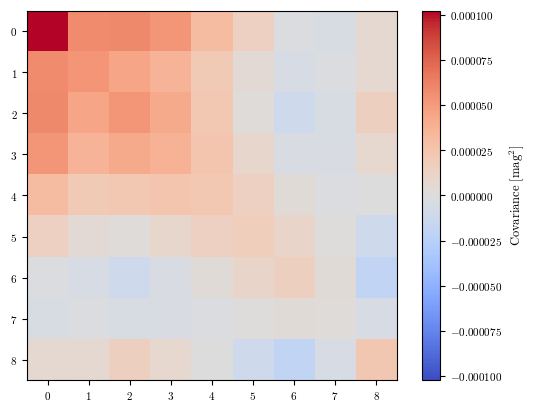

In [54]:
vmax = np.max(np.abs(y_cov))
img = plt.imshow(y_cov, cmap="coolwarm", vmin=-vmax, vmax=vmax)
plt.colorbar(img, label="Covariance [mag$^2$]")

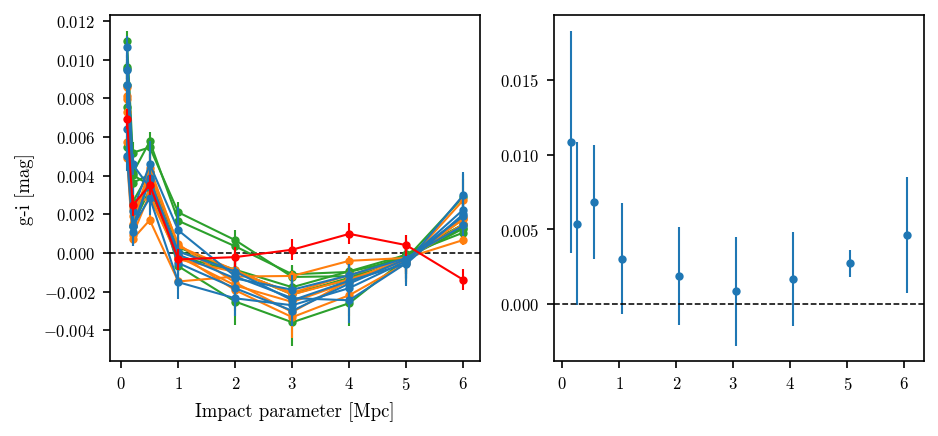

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), dpi=150)


def get_color(i):
    if i == 0:
        return "r"
    elif i <= 5:
        return "C0"
    elif i <= 11:
        return "C1"
    else:
        return "C2"


y_all = []
for i in results:
    x = results[i]["g-i_bin_centers"]
    y = -2.5 * np.log10(results[i]["g-i_avg"])
    y_err = results[i]["g-i_err"]
    ax1.errorbar(
        x, y, yerr=y_err, label=f"JK {i}", marker=".", color=get_color(i), zorder=20 - i
    )
    y_all.append(y)
ax1.set(xlabel="Impact parameter [Mpc]", ylabel="g-i [mag]")

x_all = x.copy()
y_all = np.array(y_all) + 3e-3

y_mean = np.mean(y_all, axis=0)
# y_cov = np.cov(y_all, rowvar=False)
y_cov = np.cov(y_all, rowvar=False, bias=True) * (len(y_all) - 1)


ax2.errorbar(x_all + 0.05, y_mean, yerr=np.sqrt(np.diag(y_cov)), marker=".", ls="")

ax1.axhline(0, c="k", ls="--", lw=0.75)
ax2.axhline(0, c="k", ls="--", lw=0.75)
# plt.legend()